<a href="https://colab.research.google.com/github/yudiii96/MESIN-PENERJEMAH/blob/main/MESIN_PENERJEMAH_BAHASA_BUGIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Translation with BERT

In [ ]:
# install library
!pip install sacrebleu --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.1 MB/s eta 0:00:00


In [ ]:
# import library
import pandas as pd
import numpy as np
import torch
import re
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Trainer, TrainingArguments, AutoModel, EncoderDecoderModel
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
from sacrebleu import corpus_bleu
import matplotlib.pyplot as plt
from datasets import Dataset

In [ ]:
# path dataset
test = '/content/test.csv' # ambil data test karena 10000 sudah cukup

# load dataset
df = pd.read_csv(test)

# split: 80% train_val dan 20% test
df_train_val, df_test = train_test_split(df, test_size=0.2, random_state=42)

# split again: 87.5% train dan 12.5% val from train_val (to makesure val into 10% from total)
df_train, df_val = train_test_split(df_train_val, test_size=0.125, random_state=42)

# reset index
for df in [df_train, df_val, df_test]:
    df.reset_index(drop=True, inplace=True)

In [ ]:
# train head
df_train.head()

,original,translated
0,"""Atletico memang menghadapi sebuah tugas sulit...","""Atletico memeng siolong sebuah tugas masussa ..."
1,"""Gereja Katolik Armenia juga adalah sebutan da...","""Gereja Katolik Armenia aga yaro lae asengi po..."
2,"""Dapat dijumpai definisi bahan kimia atau zat ...","""Naulle dijumpai definisi bahan kimia arega za..."
3,"menurut eko b. supriyanto , ceo the finance , ...","menuru' eko b supriyanto , ceo ero adduikeng ,..."
4,"""Jurnalisme imersif adalah bentuk dari sebuah ...","""Jurnalisme imersif iyana seddi bentu' pole ri..."


In [ ]:
# test head
df_test.head()

,original,translated
0,"Ketika bergulirnya reformasi, Muhidi memilih t...","Wettunna jokka reformasi, Muhidi napitte tama ..."
1,Saya selalu tertarik pada orang yang jarang di...,Iya' sangi' tertarik akko tau yaro masagala ri...
2,Korea Utara memperingatkan Jepang agar tidak b...,Korea Utara naperhatikanggi Jepang de'na maelo...
3,Jokowi mengajak Jan Ethes bermain dan membeli ...,Jokowi naera Jan Ethes maccule nennia melli te...
4,"""Dan Cermin Pun Retak atau The Mirror Crack'd ...","""Na Camming Pun Retak yarega The Mirror Crack'..."


In [ ]:
# val head
df_val.head()

,original,translated
0,"""Theophilus Ebenhaezer (Eben) Dönges (lahir di...","""Theophilus Ebenhaezer (Eben) Dönges (caji ku ..."
1,"""Sistem lainnya dapat pula dirujuk sebagai ato...","""Sistem lainna engka tofa irujuk mancaji atom ..."
2,KPK masih membahas untuk menerbitkan surat DPO...,KPK nabahas mopi untuk naterbitkan surek DPO o...
3,Manajemen memutuskan untuk melakukan penataan ...,Manajemen napettui untuk ma'jama penataan orga...
4,"""Pada tahun 1915, Cyril Alington, yang menjadi...","""Akko taung 1915, Cyril Alington, iyae mancaji..."


In [ ]:
# cek shape pada tiap dataset
print('shape train dataset', df_train.shape)
print('shape test dataset', df_test.shape)
print('shape val dataset', df_val.shape)

shape train dataset (7000, 2)
shape test dataset (2000, 2)
shape val dataset (1000, 2)


In [ ]:
# function for cleaning
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", "", text)  # remove html
    text = re.sub(r"\s+", " ", text)   # normalize space
    text = re.sub(r"[^\w\s.,!?]", "", text)  # keep basic punct
    return text.strip()

# apply function
for df in [df_train, df_val, df_test]:
    df['original'] = df['original'].astype(str).apply(clean_text)
    df['translated'] = df['translated'].astype(str).apply(clean_text)

# reverse arah translasi
for df in [df_train, df_val, df_test]:
    df[['original', 'translated']] = df[['translated', 'original']]

In [ ]:
# cek hasil reverse
df_train.head()

,original,translated
0,Atletico memeng siolong sebuah tugas masussa n...,Atletico memang menghadapi sebuah tugas sulit ...
1,Gereja Katolik Armenia aga yaro lae asengi pol...,Gereja Katolik Armenia juga adalah sebutan dar...
2,Naulle dijumpai definisi bahan kimia arega zat...,Dapat dijumpai definisi bahan kimia atau zat k...
3,"menuru eko b supriyanto , ceo ero adduikeng , ...","menurut eko b. supriyanto , ceo the finance , ..."
4,Jurnalisme imersif iyana seddi bentu pole ri s...,Jurnalisme imersif adalah bentuk dari sebuah p...


In [ ]:
# preprocessing
def preprocess_data(df):
    return Dataset.from_pandas(df[['original', 'translated']])

train_dataset = preprocess_data(df_train)
test_dataset = preprocess_data(df_test)
val_dataset = preprocess_data(df_val)

In [ ]:
# cek result
train_dataset, test_dataset, val_dataset

(Dataset({
     features: ['original', 'translated'],
     num_rows: 7000
 }),
 Dataset({
     features: ['original', 'translated'],
     num_rows: 2000
 }),
 Dataset({
     features: ['original', 'translated'],
     num_rows: 1000
 }))

In [ ]:
# use model indobert
model = EncoderDecoderModel.from_encoder_decoder_pretrained("indobenchmark/indobert-base-p1", "indobenchmark/indobert-base-p1")
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

# set special tokens
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.pad_token_id = tokenizer.pad_token_id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
[transformers] BertLMHeadModel LOAD REPORT from: indobenchmark/indobert-base-p1
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
pooler.dense.bias                                                  | UNEXPECTED | 
pooler.dense.weight                                                | UNEXPECTED | 
bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.weight | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.dense.bias       | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.query.bias         | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.query.weight       | MISSIN

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# function preprocessing for translation
def tokenize_function(examples):
    inputs = tokenizer(
        examples['original'],
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    targets = tokenizer(
        examples['translated'],
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    inputs['labels'] = targets['input_ids']
    return inputs

# tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Epoch,Training Loss,Validation Loss


In [ ]:
# set decoder_start_token_id
model.config.decoder_start_token_id = tokenizer.cls_token_id

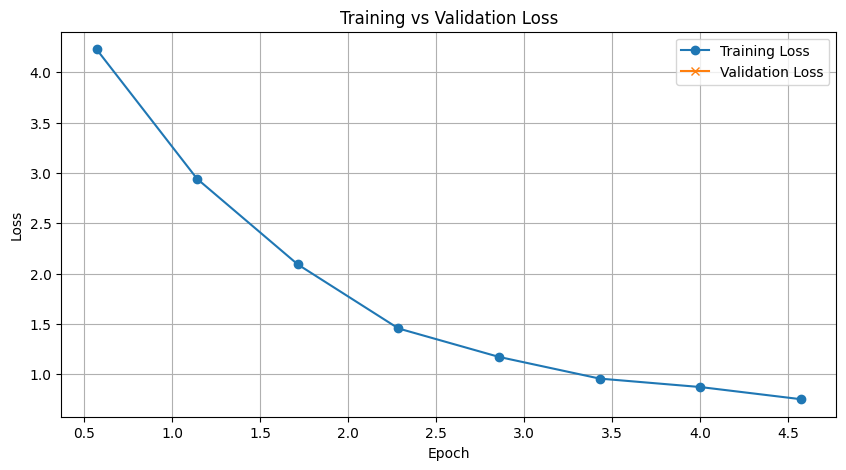

In [ ]:
# save log history
train_history = trainer.state.log_history

df_log = pd.DataFrame(train_history)
df_log = df_log.dropna(subset=['loss'])

# visualize
plt.figure(figsize=(10, 5))
plt.plot(df_log["epoch"], df_log["loss"], label="Training Loss", marker='o')
if 'eval_loss' in df_log.columns:
    df_eval = df_log.dropna(subset=['eval_loss'])
    plt.plot(df_eval["epoch"], df_eval["eval_loss"], label="Validation Loss", marker='x')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
# function for generate translation
def generate_translations(model, tokenizer, test_data):
    model.eval()
    translations = []

    for example in test_data:
        inputs = tokenizer(
            example['original'],
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=128
        )

        input_ids = inputs['input_ids'].to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=inputs['attention_mask'],
                max_length=128,
                num_beams=1,
                #early_stopping=True,
                decoder_start_token_id=model.config.decoder_start_token_id
            )

        translation = tokenizer.decode(outputs[0], skip_special_tokens=True)
        translations.append(translation)

    return translations

# applu function
predictions = generate_translations(model, tokenizer, test_dataset)

# calculate BLEU score
references = [example['translated'] for example in test_dataset]
bleu_score = corpus_bleu(predictions, [references])

print(f"BLEU Score: {bleu_score.score:.4f}")

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


BLEU Score: 24.3744


In [ ]:
from nltk.translate.bleu_score import SmoothingFunction
smoothie = SmoothingFunction().method4

# Ulangi evaluasi dengan smoothing
bleu_scores = [
    sentence_bleu([ref.split()], pred.split(), smoothing_function=smoothie)
    for pred, ref in zip(predictions, references)
]


In [ ]:
# take data test
originals = [example['original'] for example in test_dataset]
references = [example['translated'] for example in test_dataset]
predictions = generate_translations(model, tokenizer, test_dataset)

# calculate individual BLEU
bleu_scores = [
    sentence_bleu([ref.split()], pred.split())
    for pred, ref in zip(predictions, references)
]

# save to df
df_results = pd.DataFrame({
    "original": originals,
    "translated": references,
    "predicted": predictions,
    "bleu": bleu_scores
})

df_results.head()

/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

,original,translated,predicted,bleu
0,"Wettunna jokka reformasi, Muhidi napitte tama ...","Ketika bergulirnya reformasi, Muhidi memilih t...","ketika menuju reformasi, muhidi memutuskan ke ...",1.715127e-01
1,Iya sangi tertarik akko tau yaro masagala riru...,Saya selalu tertarik pada orang yang jarang di...,saya merasa tertarik pada orang yang pernah di...,1.460839e-01
2,Korea Utara naperhatikanggi Jepang dena maelo ...,Korea Utara memperingatkan Jepang agar tidak b...,korea utara menjelaskan jepang tidak akan bert...,2.202816e-78
3,Jokowi naera Jan Ethes maccule nennia melli te...,Jokowi mengajak Jan Ethes bermain dan membeli ...,jokowi membawa jan ethes bermain dan membeli t...,9.781699e-02
4,Na Camming Pun Retak yarega The Mirror Crackd ...,Dan Cermin Pun Retak atau The Mirror Crackd fr...,dan camming pun retak atau the mirror patchd f...,3.099413e-01


In [ ]:
# function for testing model
def translate_text(text, model, tokenizer, max_length=128, num_beams=4):
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=max_length
    )

    inputs = {key: val.to(model.device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True,
            decoder_start_token_id=model.config.decoder_start_token_id
        )

    translation = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return translation

# example
input_text = 'Gereja Katolik Armenia aga yaro lae asengi'
translated_text = translate_text(input_text, model, tokenizer)
print('Hasil Translasi:', translated_text)

Hasil Translasi: gereja katolik armenia juga yang telah disebut namanya katolikenia juga disebut nama ini. gereja katolik juga disebut


In [ ]:
# Function to translate a single sentence
def translate_text(text, model, tokenizer, max_length=128, num_beams=4):
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=max_length
    )

    inputs = {key: val.to(model.device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True,
            decoder_start_token_id=model.config.decoder_start_token_id
        )

    translation = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return translation

# Interactive loop for multiple translations
print("Masukkan kalimat dalam Bahasa Bugis untuk diterjemahkan ke Bahasa Indonesia.")
print("Ketik 'exit' untuk keluar.\n")

while True:
    input_text = input("Kalimat Bugis: ")

    if input_text.lower() == "exit":
        print("Terima kasih. Proses penerjemahan selesai.")
        break

    translated_text = translate_text(input_text, model, tokenizer)
    print("Hasil Translasi:", translated_text)
    print()


Masukkan kalimat dalam Bahasa Bugis untuk diterjemahkan ke Bahasa Indonesia.
Ketik 'exit' untuk keluar.



In [ ]:
# save to csv
df_results.to_csv('results.csv', index=False)

In [ ]:
# Function to translate a single sentence
def translate_text(text, model, tokenizer, max_length=128, num_beams=4):
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=max_length
    )

    inputs = {key: val.to(model.device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True,
            decoder_start_token_id=model.config.decoder_start_token_id
        )

    translation = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return translation

# Interactive loop for multiple translations
print("Masukkan kalimat dalam Bahasa Bugis untuk diterjemahkan ke Bahasa Indonesia.")
print("Ketik 'exit' untuk keluar.\n")

while True:
    input_text = input("Kalimat Bugis: ")

    if input_text.lower() == "exit":
        print("Terima kasih. Proses penerjemahan selesai.")
        break

    translated_text = translate_text(input_text, model, tokenizer)
    print("Hasil Translasi:", translated_text)
    print()


Masukkan kalimat dalam Bahasa Bugis untuk diterjemahkan ke Bahasa Indonesia.
Ketik 'exit' untuk keluar.

Kalimat Bugis: Makkungrai yewe cuku' lancar mabbahasa Sunda akki esso-essona
Hasil Translasi: wanita wanita ini sangat senang dan lancar dan lancar, lancarnya yang lancar dan lancar bahasa sunda pada hari hari ini hari ini hari ini

Kalimat Bugis: Iya' pessang sekitara' 50 kota' untu' pessangeng acara kiluarga ku
Hasil Translasi: saya dan saya, saya dan penduduk sekitar, 50 kota dan 50 kota dan untuk, untuk dan dan semua acara keluarga saya di seluruh keluarga saya saya

Kalimat Bugis: Wettu Ramalang pada iye, wisata religi okko anroang unik mancaji pilihan masyarakat.
Hasil Translasi: saat ramadan seperti ini, wisata religi pada ini, wisata religi di tempat unik menjadi pilihan masyarakat. saat ini wisata religi ke tempat masyarakat.

Kalimat Bugis: Aji de'pa naulle pannessai apakah Vizcarra naulle maccule laleng laga final e ro. Meski demikian, Aji maddenuang Vizcarra naulle patte